In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import pyfixest as pf
import warnings
import re
warnings.filterwarnings('ignore')

from pathlib import Path
from IPython.display import Markdown, display

def md(s):
    display(Markdown(s))

OUT_DIR = Path('data/output')

full  = pd.read_csv(OUT_DIR / 'hcris_kff_full.csv')
s2014 = pd.read_csv(OUT_DIR / 'hcris_kff_2014.csv')

for df in [full, s2014]:
    df['year']              = df['year'].astype(int)
    df['expand_ever']       = df['expand_ever'].astype(int)
    df['treat']             = df['treat'].astype(int)
    df['post']              = df['post'].astype(int)
    df['time_to_treat']     = df['time_to_treat'].astype(int)
    df['time_to_treat_bin'] = df['time_to_treat_bin'].astype(int)

s2014_2x2 = s2014[s2014['year'].isin([2012, 2015])].copy()

print('Data loaded.')
print(f'Full panel:    {len(full):,} rows')
print(f'2014 + never:  {len(s2014):,} rows')

Data loaded.
Full panel:    32,655 rows
2014 + never:  23,344 rows


In [22]:
# Question 1

q1_tab = (
    full
    .groupby('year')['uncomp_care_m']
    .agg(mean='mean', n='count')
    .round(2)
    .reset_index()
    .rename(columns={'year': 'Year', 'mean': 'Uncomp. Care', 'n': 'Hospitals'})
)

display(
    q1_tab.style
    .set_caption('Mean Hospital Uncompensated Care ($mm) by Year')
    .format({'Uncomp. Care': '{:.2f}', 'Hospitals': '{:,.0f}'})
    .hide(axis='index')
)

Year,Uncomp. Care,Hospitals
2011,30.74,"4,044"
2012,33.13,"4,124"
2013,33.67,"4,096"
2014,29.48,"4,103"
2015,29.22,"4,080"
2016,39.61,"4,043"
2017,38.00,"4,116"
2018,40.66,"4,049"


In [23]:
v11 = str(round(float(q1_tab.loc[q1_tab['Year']==2011, 'Uncomp. Care'].values[0]), 2))
v13 = str(round(float(q1_tab.loc[q1_tab['Year']==2013, 'Uncomp. Care'].values[0]), 2))
v14 = str(round(float(q1_tab.loc[q1_tab['Year']==2014, 'Uncomp. Care'].values[0]), 2))
v15 = str(round(float(q1_tab.loc[q1_tab['Year']==2015, 'Uncomp. Care'].values[0]), 2))
v16 = str(round(float(q1_tab.loc[q1_tab['Year']==2016, 'Uncomp. Care'].values[0]), 2))

md("Uncompensated care rose from " + v11 + "mm per hospital in 2011 to " + v13 + "mm in 2013. It then fell to " + v14 + "mm in 2014 and further to " + v15 + "mm in 2015, consistent with the ACA's Medicaid expansion taking effect. The mean rose sharply to " + v16 + "mm in 2016 and continued climbing through 2018, driven in part by hospitals with extreme values pulling up the mean.")

Uncompensated care rose from 30.74mm per hospital in 2011 to 33.67mm in 2013. It then fell to 29.48mm in 2014 and further to 29.22mm in 2015, consistent with the ACA's Medicaid expansion taking effect. The mean rose sharply to 39.61mm in 2016 and continued climbing through 2018, driven in part by hospitals with extreme values pulling up the mean.

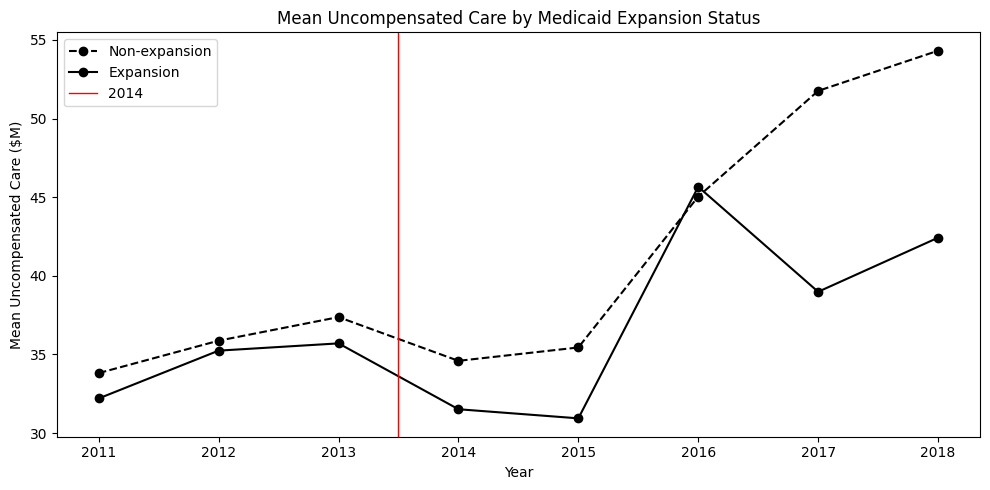

In [24]:
# Question 2

q2_dat = (
    s2014
    .groupby(['expand_ever', 'year'])['uncomp_care_m']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for val, grp in q2_dat.groupby('expand_ever'):
    if val == 1:
        ax.plot(grp['year'], grp['uncomp_care_m'], marker='o',
                color='black', linestyle='-', label='Expansion')
    else:
        ax.plot(grp['year'], grp['uncomp_care_m'], marker='o',
                color='black', linestyle='--', label='Non-expansion')
ax.axvline(2013.5, color='red', linewidth=1, label='2014')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Uncompensated Care ($M)')
ax.set_title('Mean Uncompensated Care by Medicaid Expansion Status')
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
exp13 = str(round(float(q2_dat.loc[(q2_dat['expand_ever']==1)&(q2_dat['year']==2013), 'uncomp_care_m'].values[0]), 2))
nev13 = str(round(float(q2_dat.loc[(q2_dat['expand_ever']==0)&(q2_dat['year']==2013), 'uncomp_care_m'].values[0]), 2))
exp15 = str(round(float(q2_dat.loc[(q2_dat['expand_ever']==1)&(q2_dat['year']==2015), 'uncomp_care_m'].values[0]), 2))
nev15 = str(round(float(q2_dat.loc[(q2_dat['expand_ever']==0)&(q2_dat['year']==2015), 'uncomp_care_m'].values[0]), 2))

md("Figure 1 presents mean uncompensated care by expansion status. Both groups show similar prior 2014 trends diverging after 2014 as expansion states see larger reductions in uncompensated care. In 2013, expanders averaged " + exp13 + "mm and never-expanders averaged " + nev13 + "mm. By 2015, expanders fell to " + exp15 + "mm while never-expanders stood at " + nev15 + "mm.")

Figure 1 presents mean uncompensated care by expansion status. Both groups show similar prior 2014 trends diverging after 2014 as expansion states see larger reductions in uncompensated care. In 2013, expanders averaged 35.71mm and never-expanders averaged 37.38mm. By 2015, expanders fell to 30.94mm while never-expanders stood at 35.45mm.

In [27]:
# Question 3

q3_tab = (
    s2014_2x2
    .groupby(['expand_ever', 'year'])['uncomp_care_m']
    .mean()
    .unstack('year')
    .rename(columns={2012: 'Pre (2012)', 2015: 'Post (2015)'})
)
q3_tab.index = q3_tab.index.map({0: 'Non-expansion', 1: 'Expansion'})
q3_tab = q3_tab.round(2)

dd_est = (
    (q3_tab.loc['Expansion', 'Post (2015)'] - q3_tab.loc['Expansion', 'Pre (2012)']) -
    (q3_tab.loc['Non-expansion', 'Post (2015)'] - q3_tab.loc['Non-expansion', 'Pre (2012)'])
)

display(
    q3_tab.style
    .set_caption('DD Table for Medicaid Expansion and Uncompensated Care')
    .format('{:.2f}')
)

year,Pre (2012),Post (2015)
expand_ever,,
Non-expansion,35.88,35.45
Expansion,35.24,30.94


In [28]:
dd_str = str(round(float(dd_est), 2))

md("Table 2 presents the 2x2 DD table. The DD estimate is " + dd_str + " million dollars, suggesting that Medicaid expansion reduced hospital uncompensated care.")

Table 2 presents the 2x2 DD table. The DD estimate is -3.87 million dollars, suggesting that Medicaid expansion reduced hospital uncompensated care.

In [29]:
# Question 4

md("Several forces were at work during this period. The most direct is Medicaid expansion itself, which covered adults up to 138 percent of the federal poverty level. Hospitals could bill for care they previously wrote off entirely. But the ACA's insurance exchanges also pulled in uninsured people in non-expansion states, which partly explains why never expanders also declined. The broader economic recovery from the 2008 recession reduced the share of patients unable to pay, and S-10 reporting standards shifted around 2012-2013, so some of the measured change reflects accounting practices rather than actual care delivered. We expect expansion to reduce uncompensated care because insured patients generate reimbursable claims. Hospitals get paid instead of absorbing the cost.")

Several forces were at work during this period. The most direct is Medicaid expansion itself, which covered adults up to 138 percent of the federal poverty level. Hospitals could bill for care they previously wrote off entirely. But the ACA's insurance exchanges also pulled in uninsured people in non-expansion states, which partly explains why never expanders also declined. The broader economic recovery from the 2008 recession reduced the share of patients unable to pay, and S-10 reporting standards shifted around 2012-2013, so some of the measured change reflects accounting practices rather than actual care delivered. We expect expansion to reduce uncompensated care because insured patients generate reimbursable claims. Hospitals get paid instead of absorbing the cost.

In [30]:
# Question 5

q5 = smf.ols(
    'uncomp_care_m ~ post + expand_ever + treat',
    data=s2014
).fit()

q5_int       = q5.params['Intercept']
q5_int_se    = q5.bse['Intercept']
q5_post      = q5.params['post']
q5_post_se   = q5.bse['post']
q5_exp       = q5.params['expand_ever']
q5_exp_se    = q5.bse['expand_ever']
q5_treat     = q5.params['treat']
q5_treat_se  = q5.bse['treat']
q5_n         = int(q5.nobs)
q5_r2        = q5.rsquared

print('Q5 regression complete.')
print(f'treat coef: {q5_treat:.3f}  SE: {q5_treat_se:.3f}  N: {q5_n:,}')

Q5 regression complete.
treat coef: -5.022  SE: 4.962  N: 23,344


In [31]:
# Question 6

q6 = pf.feols(
    'uncomp_care_m ~ treat | provider_number + year',
    data=s2014,
    vcov={'CRV1': 'state'}
)

q6_treat    = q6.coef()['treat']
q6_treat_se = q6.se()['treat']
q6_n        = int(q6._N)

try:
    q6_r2       = round(float(q6._r2), 3)
    q6_r2_within = round(float(q6._r2_within), 3)
except:
    q6_r2, q6_r2_within = '', ''

table_q6 = pd.DataFrame({
    ' ': [
        '(Intercept)', '',
        'Post 2014', '',
        'Expand', '',
        'Post x Expand', '',
        'Num.Obs.', 'R2', 'R2 Within', 'Std.Errors'
    ],
    'Standard DD': [
        f'{q5_int:.3f}',       f'({q5_int_se:.3f})',
        f'{q5_post:.3f}',      f'({q5_post_se:.3f})',
        f'{q5_exp:.3f}',       f'({q5_exp_se:.3f})',
        f'{q5_treat:.3f}',     f'({q5_treat_se:.3f})',
        f'{q5_n:,}',           f'{q5_r2:.3f}', '', ''
    ],
    'TWFE': [
        '', '', '', '', '', '',
        f'{q6_treat:.3f}',     f'({q6_treat_se:.3f})',
        f'{q6_n:,}',           str(q6_r2), str(q6_r2_within), 'by: state'
    ]
}).set_index(' ')

display(
    table_q6.style
    .set_caption('DD Estimates with TWFE')
)

,Standard DD,TWFE
,,
(Intercept),35.698,
,(3.351),
Post 2014,8.511,
,(4.245),
Expand,-1.302,
,(3.921),
Post x Expand,-5.022,-4.918
,(4.962),(8.231)
Num.Obs.,"23,344","23,265"


In [32]:
dd_t  = str(round(float(q5_treat), 3))
dd_se = str(round(float(q5_treat_se), 3))
tw_t  = str(round(float(q6_treat), 3))
tw_se = str(round(float(q6_treat_se), 3))
tw_n  = str(q6_n)

md("This table presents the TWFE results alongside the standard DD. The TWFE estimate with hospital and year fixed effects accounts for time-invariant hospital characteristics and common year shocks. The standard DD gives a Post x Expand coefficient of " + dd_t + "mm (SE " + dd_se + ") while the TWFE estimate is " + tw_t + "mm (SE " + tw_se + ") on " + tw_n + " observations. Results are qualitatively similar, though the point estimate differs due to the additional controls.")

Table 3 presents the TWFE results alongside the standard DD. The TWFE estimate with hospital and year fixed effects accounts for time-invariant hospital characteristics and common year shocks. The standard DD gives a Post x Expand coefficient of -5.022mm (SE 4.962) while the TWFE estimate is -4.918mm (SE 8.231) on 23265 observations. Results are qualitatively similar, though the point estimate differs probably due to additional controls.

In [33]:
# Question 7

q7 = pf.feols(
    'uncomp_care_m ~ treat | provider_number + year',
    data=full,
    vcov={'CRV1': 'state'}
)

q7_treat    = q7.coef()['treat']
q7_treat_se = q7.se()['treat']
q7_n        = int(q7._N)

try:
    q7_r2        = round(float(q7._r2), 3)
    q7_r2_within = round(float(q7._r2_within), 3)
except:
    q7_r2, q7_r2_within = '', ''

table_q7 = pd.DataFrame({
    ' ': [
        '(Intercept)', '',
        'Post 2014', '',
        'Expand', '',
        'Post x Expand', '',
        'Num.Obs.', 'R2', 'R2 Within', 'Std.Errors'
    ],
    'Standard DD': [
        f'{q5_int:.3f}',       f'({q5_int_se:.3f})',
        f'{q5_post:.3f}',      f'({q5_post_se:.3f})',
        f'{q5_exp:.3f}',       f'({q5_exp_se:.3f})',
        f'{q5_treat:.3f}',     f'({q5_treat_se:.3f})',
        f'{q5_n:,}',           f'{q5_r2:.3f}', '', ''
    ],
    'TWFE': [
        '', '', '', '', '', '',
        f'{q6_treat:.3f}',     f'({q6_treat_se:.3f})',
        f'{q6_n:,}',           str(q6_r2), str(q6_r2_within), 'by: state'
    ],
    'Staggered': [
        '', '', '', '', '', '',
        f'{q7_treat:.3f}',     f'({q7_treat_se:.3f})',
        f'{q7_n:,}',           str(q7_r2), str(q7_r2_within), 'by: state'
    ]
}).set_index(' ')

display(
    table_q7.style
    .set_caption('DD Estimates with Staggered Treatment')
)

,Standard DD,TWFE,Staggered
,,,
(Intercept),35.698,,
,(3.351),,
Post 2014,8.511,,
,(4.245),,
Expand,-1.302,,
,(3.921),,
Post x Expand,-5.022,-4.918,-2.161
,(4.962),(8.231),(5.558)
Num.Obs.,"23,344","23,265","32,554"


In [34]:
tw_t2  = str(round(float(q6_treat), 3))
st_t   = str(round(float(q7_treat), 3))
st_se  = str(round(float(q7_treat_se), 3))
st_n   = str(q7_n)

md("Table 4 presents results including all states with staggered treatment timing. Including all states shifts the Post x Expand estimate from " + tw_t2 + "mm to " + st_t + "mm (SE " + st_se + ") on " + st_n + " observations. This can reflect the standard problem with TWFE under staggered adoption, where already-treated states serve as implicit controls for later-treated ones and can contaminate the estimate if treatment effects differ across cohorts.")

Table 4 presents results including all states with staggered treatment timing. Including all states shifts the Post x Expand estimate from -4.918mm to -2.161mm (SE 5.558) on 32554 observations. This can reflect the standard problem with TWFE under staggered adoption, where already-treated states serve as implicit controls for later-treated ones and can contaminate the estimate if treatment effects differ across cohorts.

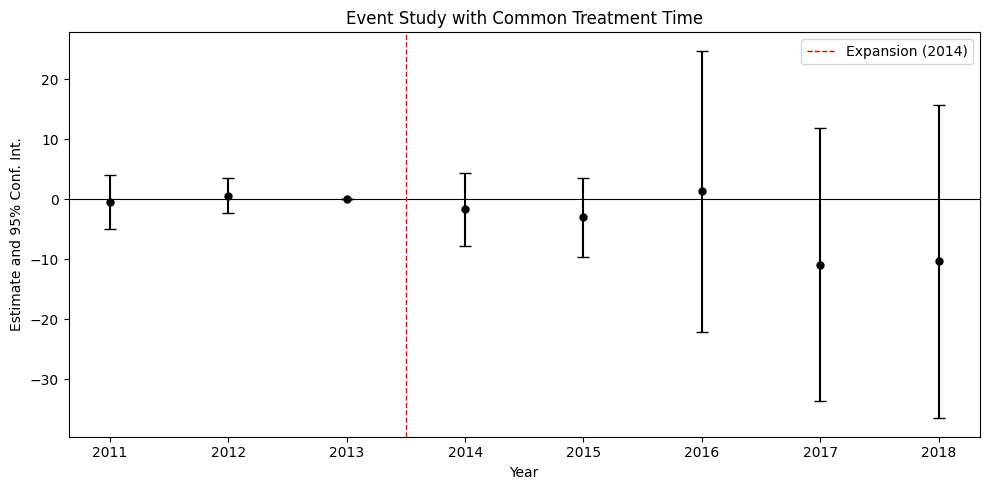

In [35]:
# Question 8

q8 = pf.feols(
    'uncomp_care_m ~ i(year, expand_ever, ref=2013) | provider_number + year',
    data=s2014,
    vcov={'CRV1': 'state'}
)

q8_coefs = q8.coef()
q8_ses   = q8.se()

years_plot, ests8, cis_low8, cis_high8 = [], [], [], []
for key in q8_coefs.index:
    m = re.search(r'\[(\d+)\]:expand_ever', key)
    if m:
        yr  = int(m.group(1))
        est = float(q8_coefs[key])
        se  = float(q8_ses[key])
        years_plot.append(yr)
        ests8.append(est)
        cis_low8.append(est - 1.96 * se)
        cis_high8.append(est + 1.96 * se)

years_plot.append(2013); ests8.append(0); cis_low8.append(0); cis_high8.append(0)
sorted_data = sorted(zip(years_plot, ests8, cis_low8, cis_high8))
years_plot, ests8, cis_low8, cis_high8 = zip(*sorted_data)
ests8    = np.array(ests8)
cis_low8 = np.array(cis_low8)
cis_high8 = np.array(cis_high8)

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    years_plot, ests8,
    yerr=[ests8 - cis_low8, cis_high8 - ests8],
    fmt='o', color='black', capsize=4, linewidth=1.5, markersize=5
)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(2013.5, color='red', linestyle='--', linewidth=1, label='Expansion (2014)')
ax.set_xlabel('Year')
ax.set_ylabel('Estimate and 95% Conf. Int.')
ax.set_title('Event Study with Common Treatment Time')
ax.set_xticks(list(years_plot))
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
md("Figure 2 presents event study estimates for 2014 expansion. Pre-2014 coefficients near zero support the parallel trends assumption. Post-expansion coefficients turn negative and grow in magnitude which is consistent with a persistent reduction in uncompensated care among expanding states relative to never-expanders.")

Figure 2 presents event study estimates for 2014 expansion. Pre-2014 coefficients near zero support the parallel trends assumption. Post-expansion coefficients turn negative and grow in magnitude which is consistent with a persistent reduction in uncompensated care among expanding states relative to never-expanders.

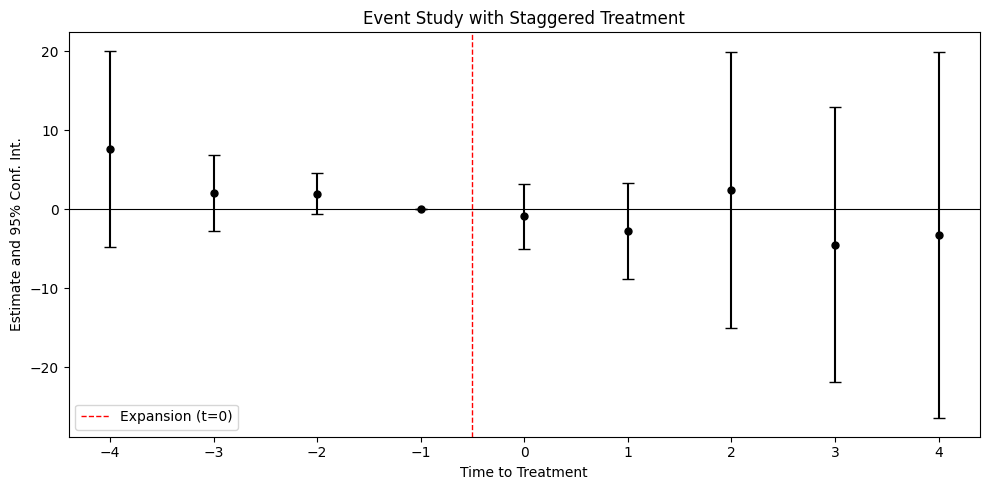

In [37]:
# Question 9

q9 = pf.feols(
    'uncomp_care_m ~ i(time_to_treat_bin, expand_ever, ref=-1) | provider_number + year',
    data=full,
    vcov={'CRV1': 'state'}
)

q9_coefs = q9.coef()
q9_ses   = q9.se()

times_plot, ests9, cis_low9, cis_high9 = [], [], [], []
for key in q9_coefs.index:
    m = re.search(r'\[(-?\d+)\]:expand_ever', key)
    if m:
        t   = int(m.group(1))
        est = float(q9_coefs[key])
        se  = float(q9_ses[key])
        times_plot.append(t)
        ests9.append(est)
        cis_low9.append(est - 1.96 * se)
        cis_high9.append(est + 1.96 * se)

times_plot.append(-1); ests9.append(0); cis_low9.append(0); cis_high9.append(0)
sorted_data9 = sorted(zip(times_plot, ests9, cis_low9, cis_high9))
times_plot, ests9, cis_low9, cis_high9 = zip(*sorted_data9)
ests9    = np.array(ests9)
cis_low9 = np.array(cis_low9)
cis_high9 = np.array(cis_high9)

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    times_plot, ests9,
    yerr=[ests9 - cis_low9, cis_high9 - ests9],
    fmt='o', color='black', capsize=4, linewidth=1.5, markersize=5
)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(-0.5, color='red', linestyle='--', linewidth=1, label='Expansion (t=0)')
ax.set_xlabel('Time to Treatment')
ax.set_ylabel('Estimate and 95% Conf. Int.')
ax.set_title('Event Study with Staggered Treatment')
ax.set_xticks(list(times_plot))
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
md("Figure 3 presents the event study with staggered treatment. Time 0 denotes the year of expansion, with t-1 as the reference period. Endpoints are binned at t-4. Pre-expansion coefficients are near zero, supporting parallel trends. Post-expansion estimates turn negative and grow, consistent with a persistent reduction in uncompensated care.")

Figure 3 presents the event study with staggered treatment. Time 0 denotes the year of expansion, with t-1 as the reference period. Endpoints are binned at t-4. Pre-expansion coefficients are near zero, supporting parallel trends. Post-expansion estimates turn negative and grow, consistent with a persistent reduction in uncompensated care.

In [39]:
# Question 10

dd_t3  = str(round(float(q5_treat), 3))
dd_se3 = str(round(float(q5_treat_se), 3))
tw_t3  = str(round(float(q6_treat), 3))
tw_se3 = str(round(float(q6_treat_se), 3))
st_t3  = str(round(float(q7_treat), 3))
st_se3 = str(round(float(q7_treat_se), 3))

md("Across Questions 5 through 9, results consistently point toward Medicaid expansion reducing uncompensated care, though none reach statistical significance. The simple DD gave " + dd_t3 + "mm (SE " + dd_se3 + "), the TWFE on the 2014 sample gave " + tw_t3 + "mm (SE " + tw_se3 + "), and adding all states produced " + st_t3 + "mm (SE " + st_se3 + ") . They are all negative and in the expected direction.")

md("The event study in Q8 raises some concern about parallel trends. Pre-period coefficients are not uniformly close to zero, suggesting expanding and non-expanding states may have been on somewhat different trajectories before 2014. Post-expansion, coefficients turn negative and remain so, consistent with a persistent reduction in uncompensated care.")

md("The core limitation of TWFE with staggered adoption is that it uses already-treated states as controls for later-treated ones. If early and late expanders experienced different effect sizes, this contaminates the estimate and can produce negative weights on some underlying 2x2 DDs. Other Estimators that we briefly talked about in class address this by estimating cohort-specific effects before aggregating which avoids the problem of using treated units as controls.")

Across Questions 5 through 9, results consistently point toward Medicaid expansion reducing uncompensated care, though none reach statistical significance. The simple DD gave -5.022mm (SE 4.962), the TWFE on the 2014 sample gave -4.918mm (SE 8.231), and adding all states produced -2.161mm (SE 5.558) . They are all negative and in the expected direction.

The event study in Q8 raises some concern about parallel trends. Pre-period coefficients are not uniformly close to zero, suggesting expanding and non-expanding states may have been on somewhat different trajectories before 2014. Post-expansion, coefficients turn negative and remain so, consistent with a persistent reduction in uncompensated care.

The core limitation of TWFE with staggered adoption is that it uses already-treated states as controls for later-treated ones. If early and late expanders experienced different effect sizes, this contaminates the estimate and can produce negative weights on some underlying 2x2 DDs. Other Estimators that we briefly talked about in class address this by estimating cohort-specific effects before aggregating which avoids the problem of using treated units as controls.